# 👋 PyCaret Time Series Forecasting Tutorial

In [1]:
import pycaret
# import pycaret time series and init setup
from pycaret.time_series import *
### loading sample dataset from pycaret dataset module
from pycaret.datasets import get_data

In [3]:
def clear_disp():
    res = pull()
    display(
        res.style
        .set_properties(**{
            "color": "#111",
            "background-color": "#fff"
        })
    )

# 🚀 Quick start

PyCaret's time series forecasting module is now available. The module currently is suitable for univariate / multivariate time series forecasting tasks. The API of time series module is consistent with other modules of PyCaret.

It comes built-in with preprocessing capabilities and over 30 algorithms comprising of statistical / time-series methods as well as machine learning based models. In addition to the model training, this module has lot of other capabilities such as automated hyperparameter tuning, ensembling, model analysis, model packaging and deployment capabilities. 

A typical workflow in PyCaret consist of following 5 steps in this order:

### **Setup** ➡️ **Compare Models** ➡️ **Analyze Model** ➡️ **Prediction** ➡️ **Save Model** <br/>

In [4]:
data = get_data('airline')

Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
Freq: M, Name: Number of airline passengers, dtype: float64

In [5]:
data.tail()

Period
1960-08    606.0
1960-09    508.0
1960-10    461.0
1960-11    390.0
1960-12    432.0
Freq: M, Name: Number of airline passengers, dtype: float64

<Axes: xlabel='Period'>

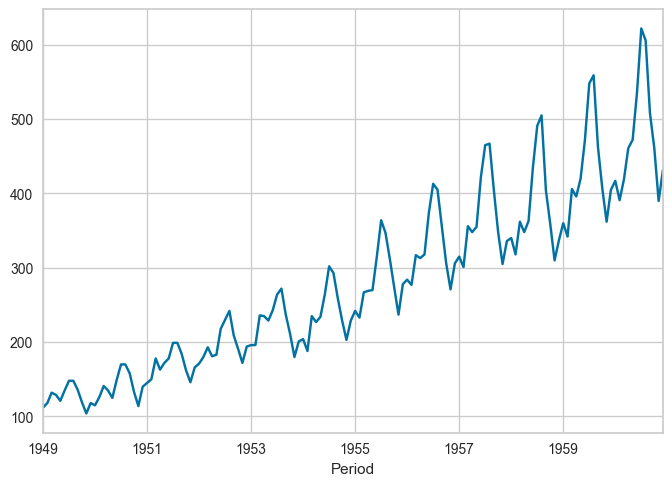

In [6]:
# plot the dataset
data.plot()

## Setup
This function initializes the training environment and creates the transformation pipeline. Setup function must be called before executing any other function in PyCaret. `Setup` has only one required parameter i.e. `data`. All the other parameters are optional.

In [7]:
s = setup(data, fh = 3, session_id = 123,verbose=False)
clear_disp()


,Description,Value
0,session_id,123
1,Target,Number of airline passengers
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(144, 1)"
5,Transformed data shape,"(144, 1)"
6,Transformed train set shape,"(141, 1)"
7,Transformed test set shape,"(3, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


Once the setup has been successfully executed it shows the information grid containing experiment level information. 

- **Session id:**  A pseudo-random number distributed as a seed in all functions for later reproducibility. If no `session_id` is passed, a random number is automatically generated that is distributed to all functions.<br/>
<br/>
- **Approach:**  Univariate or multivariate. <br/>
<br/>
- **Exogenous Variables:**  Exogeneous variables to be used in model. <br/>
<br/>
- **Original data shape:**  Shape of the original data prior to any transformations. <br/>
<br/>
- **Transformed train set shape :**  Shape of transformed train set <br/>
<br/>
- **Transformed test set shape :**  Shape of transformed test set <br/>
<br/>

PyCaret has two set of API's that you can work with. (1) Functional (as seen above) and (2) Object Oriented API.

With Object Oriented API instead of executing functions directly you will import a class and execute methods of class.

## Check Stats
The `check_stats` function is used to get summary statistics and run statistical tests on the original data or model residuals.

In [8]:
# check statistical tests on original data
check_stats()

,Test,Test Name,Data,Property,Setting,Value
0,Summary,Statistics,Transformed,Length,,144.0
1,Summary,Statistics,Transformed,# Missing Values,,0.0
2,Summary,Statistics,Transformed,Mean,,280.298611
3,Summary,Statistics,Transformed,Median,,265.5
4,Summary,Statistics,Transformed,Standard Deviation,,119.966317
5,Summary,Statistics,Transformed,Variance,,14391.917201
6,Summary,Statistics,Transformed,Kurtosis,,-0.364942
7,Summary,Statistics,Transformed,Skewness,,0.58316
8,Summary,Statistics,Transformed,# Distinct Values,,118.0
9,White Noise,Ljung-Box,Transformed,Test Statictic,"{'alpha': 0.05, 'K': 24}",1606.083817


## Compare Models

This function trains and evaluates the performance of all the estimators available in the model library using cross-validation. The output of this function is a scoring grid with average cross-validated scores. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [9]:
# compare baseline models
best = compare_models(verbose=False)
clear_disp()

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
stlf,STLF,0.413600,0.453000,12.737300,15.827200,0.026200,0.026100,0.201600,0.026700
ets,ETS,0.491200,0.554100,15.093800,19.309800,0.031800,0.031600,-0.446400,0.053300
exp_smooth,Exponential Smoothing,0.492900,0.556100,15.147800,19.379200,0.032000,0.031700,-0.460500,0.046700
arima,ARIMA,0.696400,0.711000,21.375700,24.777400,0.044700,0.045600,-0.549500,0.926700
auto_arima,Auto ARIMA,0.713600,0.694500,21.939000,24.213800,0.045900,0.046400,-0.545400,9.396700
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.865800,0.836200,26.782600,29.394700,0.051600,0.053600,0.150100,0.180000
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.890400,0.872200,27.526600,30.624300,0.053400,0.055500,-0.009200,0.310000
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.890500,0.872200,27.527000,30.624600,0.053400,0.055500,-0.009200,0.296700
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.894400,0.874600,27.653500,30.712700,0.053500,0.055700,-0.006300,0.200000
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.896600,0.875900,27.723100,30.759400,0.053600,0.055800,-0.004000,0.240000


## Analyze Model

You can use the `plot_model` function to analyzes the performance of a trained model on the test set. It may require re-training the model in certain cases.

In [10]:
# plot forecast
plot_model(best, plot = 'forecast')

In [11]:
# plot forecast for 36 months in future
plot_model(best, plot = 'forecast', data_kwargs = {'fh' : 36})

In [12]:
# residuals plot
plot_model(best, plot = 'residuals')

## Prediction
The `predict_model` function returns `y_pred`. When data is `None` (default), it uses `fh` as defined during the `setup` function. 

In [13]:
# predict on test set
holdout_pred = predict_model(best)

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,STLF,0.3305,0.3157,10.5518,11.4475,0.0255,0.0252,0.8457


In [14]:
data.tail(3)

Period
1960-10    461.0
1960-11    390.0
1960-12    432.0
Freq: M, Name: Number of airline passengers, dtype: float64

In [15]:
# show predictions df
holdout_pred.head()

,y_pred
1960-10,455.2909
1960-11,406.4324
1960-12,441.5140


In [16]:
# generate forecast for 36 period in future
predict_model(best, fh = 36)

,y_pred
1960-10,455.2909
1960-11,406.4324
1960-12,441.5140
1961-01,456.2386
1961-02,430.1439
1961-03,471.7323
1961-04,490.5395
1961-05,507.2320
1961-06,567.3178
1961-07,650.9920


# 👇 Detailed function-by-function overview

## ✅ Setup
This function initializes the training environment and creates the transformation pipeline. Setup function must be called before executing any other function in PyCaret. `Setup` has only one required parameter i.e. `data`. All the other parameters are optional.

In [17]:
s = setup(data, fh = 3, session_id = 123,verbose=False)
clear_disp()

,Description,Value
0,session_id,123
1,Target,Number of airline passengers
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(144, 1)"
5,Transformed data shape,"(144, 1)"
6,Transformed train set shape,"(141, 1)"
7,Transformed test set shape,"(3, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


To access all the variables created by the setup function such as transformed dataset, random_state, etc. you can use `get_config` method.

In [18]:
# check all available config
get_config()

{'USI',
 'X',
 'X_test',
 'X_test_transformed',
 'X_train',
 'X_train_transformed',
 'X_transformed',
 '_available_plots',
 '_ml_usecase',
 'all_sps_to_use',
 'approach_type',
 'candidate_sps',
 'data',
 'dataset',
 'dataset_transformed',
 'enforce_exogenous',
 'enforce_pi',
 'exogenous_present',
 'exp_id',
 'exp_name_log',
 'fh',
 'fold_generator',
 'fold_param',
 'gpu_n_jobs_param',
 'gpu_param',
 'html_param',
 'idx',
 'index_type',
 'is_multiclass',
 'log_plots_param',
 'logging_param',
 'memory',
 'model_engines',
 'n_jobs_param',
 'pipeline',
 'primary_sp_to_use',
 'seasonality_present',
 'seed',
 'significant_sps',
 'significant_sps_no_harmonics',
 'strictly_positive',
 'test',
 'test_transformed',
 'train',
 'train_transformed',
 'variable_and_property_keys',
 'variables',
 'y',
 'y_test',
 'y_test_transformed',
 'y_train',
 'y_train_transformed',
 'y_transformed'}

In [19]:
# lets access y_train_transformed
get_config('y_train_transformed')

Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
           ...  
1960-05    472.0
1960-06    535.0
1960-07    622.0
1960-08    606.0
1960-09    508.0
Freq: M, Name: Number of airline passengers, Length: 141, dtype: float64

In [20]:
# another example: let's access seed
print("The current seed is: {}".format(get_config('seed')))

# now lets change it using set_config
set_config('seed', 786)
print("The new seed is: {}".format(get_config('seed')))

The current seed is: 123
The new seed is: 786


In [21]:
# init setup fold_strategy = expanding
s = setup(data, fh = 3, session_id = 123,
          fold_strategy = 'expanding', numeric_imputation_target = 'drift',verbose=False)
clear_disp()

,Description,Value
0,session_id,123
1,Target,Number of airline passengers
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(144, 1)"
5,Transformed data shape,"(144, 1)"
6,Transformed train set shape,"(141, 1)"
7,Transformed test set shape,"(3, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


## ✅ Compare Models
This function trains and evaluates the performance of all estimators available in the model library using cross-validation. The output of this function is a scoring grid with average cross-validated scores. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [22]:
best = compare_models(verbose=False)
clear_disp()

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
stlf,STLF,0.413600,0.453000,12.737300,15.827200,0.026200,0.026100,0.201600,0.033300
ets,ETS,0.491200,0.554100,15.093800,19.309800,0.031800,0.031600,-0.446400,0.056700
exp_smooth,Exponential Smoothing,0.492900,0.556100,15.147800,19.379200,0.032000,0.031700,-0.460500,0.056700
arima,ARIMA,0.696400,0.711000,21.375700,24.777400,0.044700,0.045600,-0.549500,0.066700
auto_arima,Auto ARIMA,0.713600,0.694500,21.939000,24.213800,0.045900,0.046400,-0.545400,8.773300
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.865800,0.836200,26.782600,29.394700,0.051600,0.053600,0.150100,0.060000
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.890400,0.872200,27.526600,30.624300,0.053400,0.055500,-0.009200,0.053300
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.890500,0.872200,27.527000,30.624600,0.053400,0.055500,-0.009200,0.056700
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.894400,0.874600,27.653500,30.712700,0.053500,0.055700,-0.006300,0.063300
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.896600,0.875900,27.723100,30.759400,0.053600,0.055800,-0.004000,0.073300


`compare_models` by default uses all the estimators in model library (all except models with `Turbo=False`) . To see all available models you can use the function `models()`

In [23]:
# check available models
models()

,Name,Reference,Turbo
ID,,,
naive,Naive Forecaster,sktime.forecasting.naive.NaiveForecaster,True
grand_means,Grand Means Forecaster,sktime.forecasting.naive.NaiveForecaster,True
snaive,Seasonal Naive Forecaster,sktime.forecasting.naive.NaiveForecaster,True
polytrend,Polynomial Trend Forecaster,sktime.forecasting.trend._polynomial_trend_for...,True
arima,ARIMA,sktime.forecasting.arima.ARIMA,True
auto_arima,Auto ARIMA,sktime.forecasting.arima.AutoARIMA,True
exp_smooth,Exponential Smoothing,sktime.forecasting.exp_smoothing.ExponentialSm...,True
ets,ETS,sktime.forecasting.ets.AutoETS,True
theta,Theta Forecaster,sktime.forecasting.theta.ThetaForecaster,True


You can use the `include` and `exclude` parameter in the `compare_models` to train only select model or exclude specific models from training by passing the model id's in `exclude` parameter.

In [24]:
compare_ts_models = compare_models(include = ['ets', 'arima', 'theta', 'naive', 'snaive', 'grand_means', 'polytrend'],verbose=False)
clear_disp()

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
ets,ETS,0.491200,0.554100,15.093800,19.309800,0.031800,0.031600,-0.446400,0.100000
arima,ARIMA,0.696400,0.711000,21.375700,24.777400,0.044700,0.045600,-0.549500,0.070000
theta,Theta Forecaster,1.083900,1.039300,33.322300,36.255500,0.068600,0.071000,-1.792600,0.043300
naive,Naive Forecaster,1.565400,1.495100,48.444400,52.523200,0.092000,0.098100,-1.834400,0.026700
snaive,Seasonal Naive Forecaster,1.674100,1.534300,51.666700,53.735000,0.105200,0.111700,-4.538800,0.050000
polytrend,Polynomial Trend Forecaster,2.155300,2.109600,66.981700,74.404800,0.124100,0.135000,-4.252500,0.036700
grand_means,Grand Means Forecaster,7.306500,6.502900,226.050200,228.388000,0.446900,0.582100,-72.118300,0.023300


In [25]:
compare_ts_models

AutoETS(seasonal='mul', sp=12, trend='add')

In [26]:
compare_ts_models_results = pull()
compare_ts_models_results

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
ets,ETS,0.4912,0.5541,15.0938,19.3098,0.0318,0.0316,-0.4464,0.1000
arima,ARIMA,0.6964,0.711,21.3757,24.7774,0.0447,0.0456,-0.5495,0.0700
theta,Theta Forecaster,1.0839,1.0393,33.3223,36.2555,0.0686,0.071,-1.7926,0.0433
naive,Naive Forecaster,1.5654,1.4951,48.4444,52.5232,0.092,0.0981,-1.8344,0.0267
snaive,Seasonal Naive Forecaster,1.6741,1.5343,51.6667,53.735,0.1052,0.1117,-4.5388,0.0500
polytrend,Polynomial Trend Forecaster,2.1553,2.1096,66.9817,74.4048,0.1241,0.135,-4.2525,0.0367
grand_means,Grand Means Forecaster,7.3065,6.5029,226.0502,228.388,0.4469,0.5821,-72.1183,0.0233


In [27]:
best_r2_models_top3 = compare_models(sort = 'R2', n_select = 3,verbose=False)
clear_disp()

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
stlf,STLF,0.413600,0.453000,12.737300,15.827200,0.026200,0.026100,0.201600,0.033300
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.865800,0.836200,26.782600,29.394700,0.051600,0.053600,0.150100,0.063300
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.896600,0.875900,27.723100,30.759400,0.053600,0.055800,-0.004000,0.200000
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,0.896600,0.875800,27.722400,30.758000,0.053600,0.055800,-0.004200,0.056700
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.894400,0.874600,27.653500,30.712700,0.053500,0.055700,-0.006300,0.053300
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.890400,0.872200,27.526600,30.624300,0.053400,0.055500,-0.009200,0.053300
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.890500,0.872200,27.527000,30.624600,0.053400,0.055500,-0.009200,0.056700
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.915600,0.887800,28.318800,31.182100,0.054700,0.056900,-0.020900,0.060000
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,1.069500,0.992400,33.150000,34.927700,0.063100,0.065600,-0.168200,0.063300
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,1.169400,1.088400,36.216000,38.272900,0.069400,0.072700,-0.435200,0.243300


In [28]:
# list of top 3 models by MAE
best_r2_models_top3

[STLForecaster(sp=12),
 BaseCdsDtForecaster(fe_target_rr=[WindowSummarizer(lag_feature={'lag': [12, 11,
                                                                         10, 9,
                                                                         8, 7, 6,
                                                                         5, 4, 3,
                                                                         2, 1]},
                                                    n_jobs=1)],
                     regressor=HuberRegressor(), sp=12, window_length=12),
 BaseCdsDtForecaster(fe_target_rr=[WindowSummarizer(lag_feature={'lag': [12, 11,
                                                                         10, 9,
                                                                         8, 7, 6,
                                                                         5, 4, 3,
                                                                         2, 1]},
                          

## ✅ Create Model
This function trains and evaluates the performance of a given estimator using cross-validation. The output of this function is a scoring grid with CV scores by fold. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function. All the available models can be accessed using the models function.

In [29]:
# train ets with default fold=3
ets = create_model('ets',verbose=False)
clear_disp()

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-12,0.508300,0.723700,15.476900,25.004200,0.037100,0.035400,-2.843500
1,1960-03,0.685600,0.626200,21.031700,21.798500,0.043700,0.044800,0.552900
2,1960-06,0.279600,0.312300,8.772900,11.126700,0.014700,0.014600,0.951200
Mean,NaT,0.491200,0.554100,15.093800,19.309800,0.031800,0.031600,-0.446400
SD,NaT,0.166200,0.175500,5.012000,5.932500,0.012400,0.012600,1.702800


The function above has return trained model object as an output. The scoring grid is only displayed and not returned. If you need access to the scoring grid you can use `pull` function to access the dataframe.

In [30]:
ets_results = pull()
print(type(ets_results))
ets_results

<class 'pandas.core.frame.DataFrame'>


,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-12,0.5083,0.7237,15.4769,25.0042,0.0371,0.0354,-2.8435
1,1960-03,0.6856,0.6262,21.0317,21.7985,0.0437,0.0448,0.5529
2,1960-06,0.2796,0.3123,8.7729,11.1267,0.0147,0.0146,0.9512
Mean,NaT,0.4912,0.5541,15.0938,19.3098,0.0318,0.0316,-0.4464
SD,NaT,0.1662,0.1755,5.0120,5.9325,0.0124,0.0126,1.7028


In [31]:
# train theta model with fold=5
theta = create_model('theta', fold=5,verbose=False)
clear_disp()

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-06,0.815200,0.821200,23.711400,27.077700,0.043600,0.044800,0.601600
1,1959-09,0.162200,0.172300,4.833900,5.821600,0.012700,0.012800,0.921300
2,1959-12,0.678800,0.785700,20.670000,27.143200,0.050100,0.048100,-3.529200
3,1960-03,2.037800,1.803700,62.507600,62.787500,0.127600,0.136300,-2.709000
4,1960-06,0.535200,0.528700,16.789500,18.835900,0.028200,0.028600,0.860300
Mean,NaT,0.845800,0.822300,25.702400,28.333200,0.052400,0.054100,-0.771000
SD,NaT,0.634600,0.542800,19.487700,18.905400,0.039700,0.043000,1.937700


In [32]:
# train theta with specific model parameters
create_model('theta', deseasonalize = False, fold=5,verbose=False)
clear_disp()

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-06,1.956800,1.960100,56.918500,64.633800,0.104400,0.111500,-1.270100
1,1959-09,2.536400,2.319800,75.572900,78.390200,0.196600,0.177400,-13.261300
2,1959-12,0.395800,0.368500,12.051500,12.730900,0.029800,0.029600,0.003600
3,1960-03,2.168800,2.116300,66.526200,73.668800,0.132400,0.143600,-4.106000
4,1960-06,1.951900,1.823800,61.236100,64.978600,0.103300,0.108100,-0.662600
Mean,NaT,1.801900,1.717700,54.461100,58.880500,0.113300,0.114000,-3.859300
SD,NaT,0.734500,0.694500,22.098800,23.661800,0.053800,0.049100,4.905200


## ✅ Tune Model

The `tune_model` function tunes the hyperparameters of the model. The output of this function is a scoring grid with cross-validated scores by fold. The best model is selected based on the metric defined in optimize parameter. Metrics evaluated during cross-validation can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [33]:
# train a dt model with default params
dt = create_model('dt_cds_dt',verbose=False)
clear_disp()

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-12,0.503900,0.545900,15.343400,18.859300,0.037700,0.038800,-1.186500
1,1960-03,1.556600,1.374700,47.748900,47.852600,0.098400,0.103600,-1.154400
2,1960-06,1.518500,1.483200,47.639500,52.843300,0.083800,0.088400,-0.099600
Mean,NaT,1.193000,1.134600,36.910600,39.851800,0.073300,0.076900,-0.813500
SD,NaT,0.487500,0.418600,15.250400,14.983100,0.025900,0.027700,0.505000


In [34]:
# tune hyperparameters of dt
tuned_dt = tune_model(dt,verbose=False)
clear_disp()

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-12,0.636900,0.782200,19.393800,27.022500,0.047000,0.045000,-3.489000
1,1960-03,1.300500,1.163900,39.893800,40.515500,0.081900,0.085600,-0.544400
2,1960-06,0.956100,0.978800,29.997100,34.874200,0.049500,0.051200,0.521100
Mean,NaT,0.964500,0.975000,29.761600,34.137400,0.059500,0.060600,-1.170800
SD,NaT,0.271000,0.155900,8.370700,5.533100,0.015900,0.017800,1.696000


Metric to optimize can be defined in `optimize` parameter (default = 'MASE'). Also, a custom tuned grid can be passed with `custom_grid` parameter. 

In [35]:
dt

BaseCdsDtForecaster(fe_target_rr=[WindowSummarizer(lag_feature={'lag': [12, 11,
                                                                        10, 9,
                                                                        8, 7, 6,
                                                                        5, 4, 3,
                                                                        2, 1]},
                                                   n_jobs=1)],
                    regressor=DecisionTreeRegressor(random_state=123), sp=12,
                    window_length=12)

In [36]:
# define tuning grid
dt_grid = {'regressor__max_depth' : [None, 2, 4, 6, 8, 10, 12]}

# tune model with custom grid and metric = MAE
tuned_dt = tune_model(dt, custom_grid = dt_grid, optimize = 'MAE',verbose=False)
clear_disp()

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-12,0.546600,0.581500,16.645000,20.091000,0.040900,0.042100,-1.481400
1,1960-03,1.277700,1.138800,39.194500,39.641900,0.079900,0.083300,-0.478500
2,1960-06,1.674200,1.526200,52.523400,54.377200,0.090600,0.095200,-0.164300
Mean,NaT,1.166200,1.082200,36.121000,38.036700,0.070500,0.073500,-0.708100
SD,NaT,0.467000,0.387700,14.807700,14.043200,0.021400,0.022700,0.561700


In [37]:
# see tuned_dt params
tuned_dt

BaseCdsDtForecaster(fe_target_rr=[WindowSummarizer(lag_feature={'lag': [12, 11,
                                                                        10, 9,
                                                                        8, 7, 6,
                                                                        5, 4, 3,
                                                                        2, 1]},
                                                   n_jobs=1)],
                    regressor=DecisionTreeRegressor(max_depth=4, random_state=123),
                    sp=12, window_length=12)

## ✅ Blend Models

This function trains a `EnsembleForecaster` for select models passed in the estimator_list parameter. The output of this function is a scoring grid with CV scores by fold. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [38]:
# top 3 models based on mae
best_r2_models_top3

[STLForecaster(sp=12),
 BaseCdsDtForecaster(fe_target_rr=[WindowSummarizer(lag_feature={'lag': [12, 11,
                                                                         10, 9,
                                                                         8, 7, 6,
                                                                         5, 4, 3,
                                                                         2, 1]},
                                                    n_jobs=1)],
                     regressor=HuberRegressor(), sp=12, window_length=12),
 BaseCdsDtForecaster(fe_target_rr=[WindowSummarizer(lag_feature={'lag': [12, 11,
                                                                         10, 9,
                                                                         8, 7, 6,
                                                                         5, 4, 3,
                                                                         2, 1]},
                          

In [39]:
# blend top 3 models
blend_models(best_r2_models_top3,verbose=False)
clear_disp()

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-12,0.244000,0.230300,7.430100,7.956900,0.018000,0.018000,0.610800
1,1960-03,1.057600,0.951000,32.442400,33.103300,0.067100,0.069600,-0.031000
2,1960-06,0.728000,0.792200,22.841100,28.225900,0.037200,0.038200,0.686300
Mean,NaT,0.676600,0.657800,20.904500,23.095400,0.040700,0.041900,0.422000
SD,NaT,0.334100,0.309200,10.302600,10.888100,0.020200,0.021200,0.321800


## ✅ Plot Model

This function analyzes the performance of a trained model on the hold-out set. It may require re-training the model in certain cases.

In [40]:
# plot forecast
plot_model(best, plot = 'forecast')

In [41]:
# plot acf
# for certain plots you don't need a trained model
plot_model(plot = 'acf')

In [42]:
# plot diagnostics
# for certain plots you don't need a trained model
plot_model(plot = 'diagnostics')